# Importing Libraries for Data Preprocessing, Visualization, and Linear Regression


In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf

# Reading the Dataset and Displaying Basic Information

In [174]:
df = pd.read_excel("Sample+data_used_cars_India.xlsx")

In [175]:
df.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,1221,Ambassador Classic Nova Diesel,Chennai,2003,80000,Diesel,Manual,Third,12.8 kmpl,1489 CC,35.5 bhp,5.0,NaN,1.35
1,398,Audi A3 35 TDI Attraction,Chennai,2014,79271,Diesel,Automatic,First,20.38 kmpl,1968 CC,143 bhp,5.0,NaN,16.50
2,4782,Audi A3 35 TDI Premium,Mumbai,2016,20003,Diesel,Automatic,First,20.38 kmpl,1968 CC,143 bhp,5.0,NaN,19.25
3,4989,Audi A3 35 TDI Premium Plus,Mumbai,2016,39000,Diesel,Automatic,First,20.38 kmpl,1968 CC,143 bhp,5.0,42.89 Lakh,18.90
4,1954,Audi A3 35 TDI Technology,Delhi,2017,22000,Diesel,Automatic,Second,20.38 kmpl,1968 CC,143 bhp,5.0,NaN,22.50


In [176]:
df.tail()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
6014,3933,Volvo XC60 D5,Hyderabad,2015,100000,Diesel,Automatic,First,13.5 kmpl,2400 CC,215 bhp,5.0,NaN,32.50
6015,4044,Volvo XC60 D5,Ahmedabad,2011,173000,Diesel,Automatic,First,13.5 kmpl,2400 CC,215 bhp,5.0,NaN,12.00
6016,1178,Volvo XC60 D5 Inscription,Kochi,2014,86925,Diesel,Automatic,First,11.2 kmpl,2400 CC,215 bhp,5.0,NaN,17.18
6017,4497,Volvo XC90 2007-2015 D5 AT AWD,Kochi,2014,102001,Diesel,Automatic,First,11.1 kmpl,2400 CC,200 bhp,7.0,NaN,23.58
6018,2401,Volvo XC90 2007-2015 D5 AWD,Kochi,2014,89230,Diesel,Manual,First,11.1 kmpl,2400 CC,200 bhp,7.0,NaN,23.65


In [177]:
df.shape

(6019, 14)

# Dataset Observations from info

In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6019 non-null   int64  
 1   Name               6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  6019 non-null   int64  
 5   Fuel_Type          6019 non-null   object 
 6   Transmission       6019 non-null   object 
 7   Owner_Type         6019 non-null   object 
 8   Mileage            6017 non-null   object 
 9   Engine             5983 non-null   object 
 10  Power              5983 non-null   object 
 11  Seats              5977 non-null   float64
 12  New_Price          824 non-null    object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 658.5+ KB


In [179]:
df['Name'].dtype

dtype('O')

### General Structure
- The dataset contains **6,019 rows** and **14 columns**, representing individual car listings.
- The data types include:
  - **Numeric (int64, float64)**: 5 columns  
  - **Categorical/Object**: 9 columns

---

### Column-wise Observations

- **`Unnamed: 0`**  
  Likely an unnecessary index column, can be dropped.

- **`Name`, `Location`, `Fuel_Type`, `Transmission`, `Owner_Type`**  
  Categorical/text fields; good candidates for encoding or feature extraction.

- **`Year`, `Kilometers_Driven`**  
  Integer fields representing the car’s manufacturing year and usage. Likely to affect price.

- **`Mileage`, `Engine`, `Power`**  
  These are numerical values stored as **object types**, likely due to units (e.g., "kmpl", "cc", "bhp") being embedded as text.  
  Require **parsing and conversion** to numerical types.

- **`Seats`**  
  Float type, but some missing values (**42 nulls**) need imputation or removal.

- **`New_Price`**  
  Contains a **large number of missing values** (only 824 non-null).  
  May not be useful for general modeling unless handled carefully.

- **`Price`**  
  Target variable representing the selling price of the car (`float64`).  
  Appears to have **no missing values**.

---

### Missing Values Summary
- `Mileage`: 2 missing  
- `Engine` and `Power`: 36 missing  
- `Seats`: 42 missing  
- `New_Price`: Significant missing data (5,195 missing)

---

### Key Actions Suggested
- Rename `Unnamed: 0` as Serial Number.
- Parse and clean `Mileage`, `Engine`, and `Power` columns.
- Impute or drop rows with missing values in `Seats`, `Mileage`, `Engine`, and `Power`.
- Consider dropping or imputing `New_Price` depending on its importance.
- Convert categorical variables for modeling (e.g., one-hot encoding or label encoding).


# Rename the column

In [180]:
df = df.rename({'Unnamed: 0':'S_No'},axis=1)

# Drop the column

In [181]:
df = df.drop("New_Price",axis=1)

# Extracting Numerical Values from Text Columns

In [182]:
x = ['Name','Mileage','Engine','Power']
for i in x:
    df[i] = df[i].str.split(" ").str[0]

## Observations

- This code processes four columns: `Name`, `Mileage`, `Engine`, and `Power`.
- It splits the string values in each column at the space `" "` and retains only the **first part** (i.e., the numeric component).

- This is particularly useful for `Mileage`, `Engine`, and `Power`, which often contain units like `"kmpl"`, `"cc"`, or `"bhp"` in string format.
  - **Example**: `"18.2 kmpl"` becomes `"18.2"`

- Extracting only the first word from the `Name` column can be useful to isolate the **car brand**, which is important for brand-level analysis or grouping.
  - **Example**: `"Hyundai i20 Magna"` becomes `"Hyundai"`, helping to focus on the manufacturer regardless of model variant.


- The extracted values for `Mileage`, `Engine`, and `Power` are still of type **object** (strings) and should be **converted to float** for numerical analysis.


# Rename the column

In [183]:
df = df.rename({'Name':'Car_Name'},axis=1)

## Converting Extracted Text Columns to Numeric Format

In [184]:
x1 = ['Mileage','Engine','Power']
for i in x1:
    df[i] = df[i].astype(str)  # Convert column to string type
    df[i] = pd.to_numeric(df[i], errors='coerce')

In [185]:
j = ['Mileage','Engine','Power']

for i in j:
    y = df[i].dtype
    print(y)

float64
float64
float64


## Observations

- This code processes the columns: `Mileage`, `Engine`, and `Power`.
- It first ensures that each column is converted to **string** type using `astype(str)`—this is a preparatory step to avoid errors during the numeric conversion.
- Then, it uses `pd.to_numeric()` with `errors='coerce'` to convert these string values into **numeric (float)** format.
  - Any value that **cannot be converted** (e.g., non-numeric strings or missing values) is replaced with `NaN`.

- This conversion is crucial because:
  - These features represent numerical characteristics of the car (e.g., mileage in kmpl, engine capacity in cc, power in bhp).
  - Converting them to a numeric type allows for **mathematical operations**, **visualizations**, and **model training**.

- As a result, the dataset becomes more suitable for **data analysis** and **machine learning tasks**.


# Average Price of Cars by Brand

In [186]:
# A = df.groupby('Car_Name')['Price'].mean()
A = df.pivot_table(values="Price",index="Car_Name",aggfunc="mean")
df1 = pd.DataFrame(A).reset_index()
df1

,Car_Name,Price
0,Ambassador,1.350000
1,Audi,25.537712
2,BMW,25.243146
3,Bentley,59.000000
4,Chevrolet,3.044463
5,Datsun,3.049231
6,Fiat,3.269286
7,Force,9.333333
8,Ford,6.889400
9,Honda,5.411743


## Observations

- This code calculates the **average selling price** for each **car brand** (assumed to be stored in a column named `Car_Name`).
- It uses `pivot_table` with:
  - `values="Price"` – the target variable.
  - `index="Car_Name"` – grouping by car brand.
  - `aggfunc="mean"` – computing the mean price.
- The result is stored in a DataFrame `A`, which is then reset to a new DataFrame `df1` with a fresh index using `reset_index()`.

# Merging Average Brand Price with Original Dataset

In [187]:
df = pd.merge(df,df1,on='Car_Name',how='inner')
df.head()

,S_No,Car_Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price_x,Price_y
0,1221,Ambassador,Chennai,2003,80000,Diesel,Manual,Third,12.80,1489.0,35.5,5.0,1.35,1.350000
1,398,Audi,Chennai,2014,79271,Diesel,Automatic,First,20.38,1968.0,143.0,5.0,16.50,25.537712
2,4782,Audi,Mumbai,2016,20003,Diesel,Automatic,First,20.38,1968.0,143.0,5.0,19.25,25.537712
3,4989,Audi,Mumbai,2016,39000,Diesel,Automatic,First,20.38,1968.0,143.0,5.0,18.90,25.537712
4,1954,Audi,Delhi,2017,22000,Diesel,Automatic,Second,20.38,1968.0,143.0,5.0,22.50,25.537712


## Observations

- This code merges the original DataFrame `df` with `df1`, which contains the **average price per car brand** (`Car_Name` and its mean `Price`).
- The merge is performed using:
  - `on='Car_Name'` – matching rows based on the car brand.
  - `how='inner'` – includes only the records that have a matching `Car_Name` in both DataFrames.

### Outcome

- The resulting `df` now contains an **additional column** (likely also named `Price` or renamed to `Price_y`) representing the **average price** for the respective car brand.
- This enables:
  - **Comparison of individual car prices** to their **brand average**.
  - Feature engineering – such as calculating price deviation from brand average.
  - Enhanced insights for **pricing strategy analysis**.


# Reordering Columns: Inserting Average Brand Price

In [188]:
df.insert(3, 'Car_num', df.pop('Price_y'))
df.head()

,S_No,Car_Name,Location,Car_num,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price_x
0,1221,Ambassador,Chennai,1.350000,2003,80000,Diesel,Manual,Third,12.80,1489.0,35.5,5.0,1.35
1,398,Audi,Chennai,25.537712,2014,79271,Diesel,Automatic,First,20.38,1968.0,143.0,5.0,16.50
2,4782,Audi,Mumbai,25.537712,2016,20003,Diesel,Automatic,First,20.38,1968.0,143.0,5.0,19.25
3,4989,Audi,Mumbai,25.537712,2016,39000,Diesel,Automatic,First,20.38,1968.0,143.0,5.0,18.90
4,1954,Audi,Delhi,25.537712,2017,22000,Diesel,Automatic,Second,20.38,1968.0,143.0,5.0,22.50


## Observations

- This code moves the `Price_y` column (which contains the **average brand price** after the merge) to a new position in the DataFrame and renames it as `Car_num`.
- It uses `df.pop('Price_y')` to:
  - Remove the `Price_y` column from its original location.
  - Return the column data for reinsertion.

- Then, `df.insert(3, 'Car_num', ...)` places it at the **3rd column index** (i.e., the 4th position in the DataFrame).

### Outcome

- The column `Car_num` now appears **early in the DataFrame**, improving visibility and organization.
- Renaming from `Price_y` to `Car_num` is a step toward clearer naming, but:
  - Consider using a more descriptive name like `Avg_Brand_Price` or `Brand_Avg_Price` for clarity.


# Average Car Price by Location

In [189]:
# B = df.groupby('Location')['Price_x'].mean()
B = df.pivot_table(values="Price_x",index="Location",aggfunc="mean")
df2 = pd.DataFrame(B).reset_index()
df2

,Location,Price_x
0,Ahmedabad,8.457321
1,Bangalore,13.328631
2,Chennai,7.753623
3,Coimbatore,15.078223
4,Delhi,9.707726
5,Hyderabad,9.776550
6,Jaipur,5.809225
7,Kochi,11.179186
8,Kolkata,5.661215
9,Mumbai,9.429329


## Observations

- This code calculates the **average car price** for each **location** based on the column `Price_x`, which represents the original car selling price.
- A pivot table is used with:
  - `values="Price_x"` – the target variable.
  - `index="Location"` – to group by city or region.
  - `aggfunc="mean"` – to compute the average price per location.

- The result is stored in a new DataFrame `df2`, with `reset_index()` applied to flatten the index for easier manipulation.


# Merging Average Location Price with Original Dataset

In [190]:
df = pd.merge(df,df2,on='Location',how='inner')
df.head()

,S_No,Car_Name,Location,Car_num,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price_x_x,Price_x_y
0,1221,Ambassador,Chennai,1.350000,2003,80000,Diesel,Manual,Third,12.80,1489.0,35.50,5.0,1.35,7.753623
1,398,Audi,Chennai,25.537712,2014,79271,Diesel,Automatic,First,20.38,1968.0,143.00,5.0,16.50,7.753623
2,1929,Audi,Chennai,25.537712,2014,70000,Diesel,Automatic,First,17.11,1968.0,174.33,5.0,18.00,7.753623
3,5776,Audi,Chennai,25.537712,2014,40000,Diesel,Automatic,First,17.11,1968.0,174.33,5.0,22.00,7.753623
4,2484,Audi,Chennai,25.537712,2016,11000,Diesel,Automatic,First,17.11,1968.0,174.33,5.0,28.00,7.753623


## Observations

- This code merges the original DataFrame `df` with `df2`, which contains the **average car price by Location**.
- The merge is done on the `Location` column using an **inner join**, meaning only rows with matching locations in both DataFrames are kept.
- After this merge, the DataFrame `df` will have an additional column (likely named `Price_x` or similar) representing the **average price for each location**.

### Outcome

- This enables:
  - Comparing individual car prices to the **average price in their location**.
  - Creating features for price prediction or analysis based on geographic pricing trends.
  - Better understanding of **regional price variations**.


# Inserting Average Location Price Column

In [191]:
df.insert(5, 'Loc_num', df.pop('Price_x_y'))
df

,S_No,Car_Name,Location,Car_num,Year,Loc_num,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price_x_x
0,1221,Ambassador,Chennai,1.350000,2003,7.753623,80000,Diesel,Manual,Third,12.80,1489.0,35.50,5.0,1.35
1,398,Audi,Chennai,25.537712,2014,7.753623,79271,Diesel,Automatic,First,20.38,1968.0,143.00,5.0,16.50
2,1929,Audi,Chennai,25.537712,2014,7.753623,70000,Diesel,Automatic,First,17.11,1968.0,174.33,5.0,18.00
3,5776,Audi,Chennai,25.537712,2014,7.753623,40000,Diesel,Automatic,First,17.11,1968.0,174.33,5.0,22.00
4,2484,Audi,Chennai,25.537712,2016,7.753623,11000,Diesel,Automatic,First,17.11,1968.0,174.33,5.0,28.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,4550,Volkswagen,Jaipur,5.307270,2015,5.809225,58000,Diesel,Manual,First,20.34,1498.0,103.20,5.0,5.85
6015,4208,Volkswagen,Jaipur,5.307270,2016,5.809225,33000,Petrol,Manual,First,16.09,1598.0,103.50,5.0,7.70
6016,844,Volkswagen,Jaipur,5.307270,2013,5.809225,125000,Diesel,Manual,Second,20.54,1598.0,103.60,5.0,6.25
6017,1536,Volkswagen,Jaipur,5.307270,2011,5.809225,50000,Diesel,Manual,First,20.54,1598.0,103.60,5.0,5.00


## Observations

- The first line moves the column `Price_x_y` (which contains the **average location price** after the merge) to position **5** (6th column) in the DataFrame and renames it to `Loc_num`.
  - `df.pop('Price_x_y')` removes the column and returns it for insertion.
  - `df.insert(5, 'Loc_num', ...)` inserts it at the desired position for better organization.

### Outcome

- Column naming and order are now clearer:
  - `Price` represents the actual selling price of each car.
  - `Loc_num` represents the average price in the car's location.
- This setup facilitates easier analysis and feature engineering, such as calculating price deviations from location averages.


# Renaming Column for Clarity

In [192]:
df = df.rename({'Price_x_x':'Price'},axis=1)
df.head()

,S_No,Car_Name,Location,Car_num,Year,Loc_num,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1221,Ambassador,Chennai,1.350000,2003,7.753623,80000,Diesel,Manual,Third,12.80,1489.0,35.50,5.0,1.35
1,398,Audi,Chennai,25.537712,2014,7.753623,79271,Diesel,Automatic,First,20.38,1968.0,143.00,5.0,16.50
2,1929,Audi,Chennai,25.537712,2014,7.753623,70000,Diesel,Automatic,First,17.11,1968.0,174.33,5.0,18.00
3,5776,Audi,Chennai,25.537712,2014,7.753623,40000,Diesel,Automatic,First,17.11,1968.0,174.33,5.0,22.00
4,2484,Audi,Chennai,25.537712,2016,7.753623,11000,Diesel,Automatic,First,17.11,1968.0,174.33,5.0,28.00


## Observations

- This code renames the column `Price_x_x` to `Price` in the DataFrame `df`.
- The original column name (`Price_x_x`) is a result of merging DataFrames with overlapping column names.
- Renaming it to `Price` improves readability and makes the dataset easier to understand.
- The `Price` column now clearly represents the **actual selling price** of each car.
- Clear and concise column names are essential for effective data analysis and avoiding confusion during further processing.


In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6019 entries, 0 to 6018
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S_No               6019 non-null   int64  
 1   Car_Name           6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Car_num            6019 non-null   float64
 4   Year               6019 non-null   int64  
 5   Loc_num            6019 non-null   float64
 6   Kilometers_Driven  6019 non-null   int64  
 7   Fuel_Type          6019 non-null   object 
 8   Transmission       6019 non-null   object 
 9   Owner_Type         6019 non-null   object 
 10  Mileage            6017 non-null   float64
 11  Engine             5983 non-null   float64
 12  Power              5876 non-null   float64
 13  Seats              5977 non-null   float64
 14  Price              6019 non-null   float64
dtypes: float64(7), int64(3), object(5)
memory usage: 752.4+ KB


# Overview of Categorical Attributes in the Car Sales Dataset

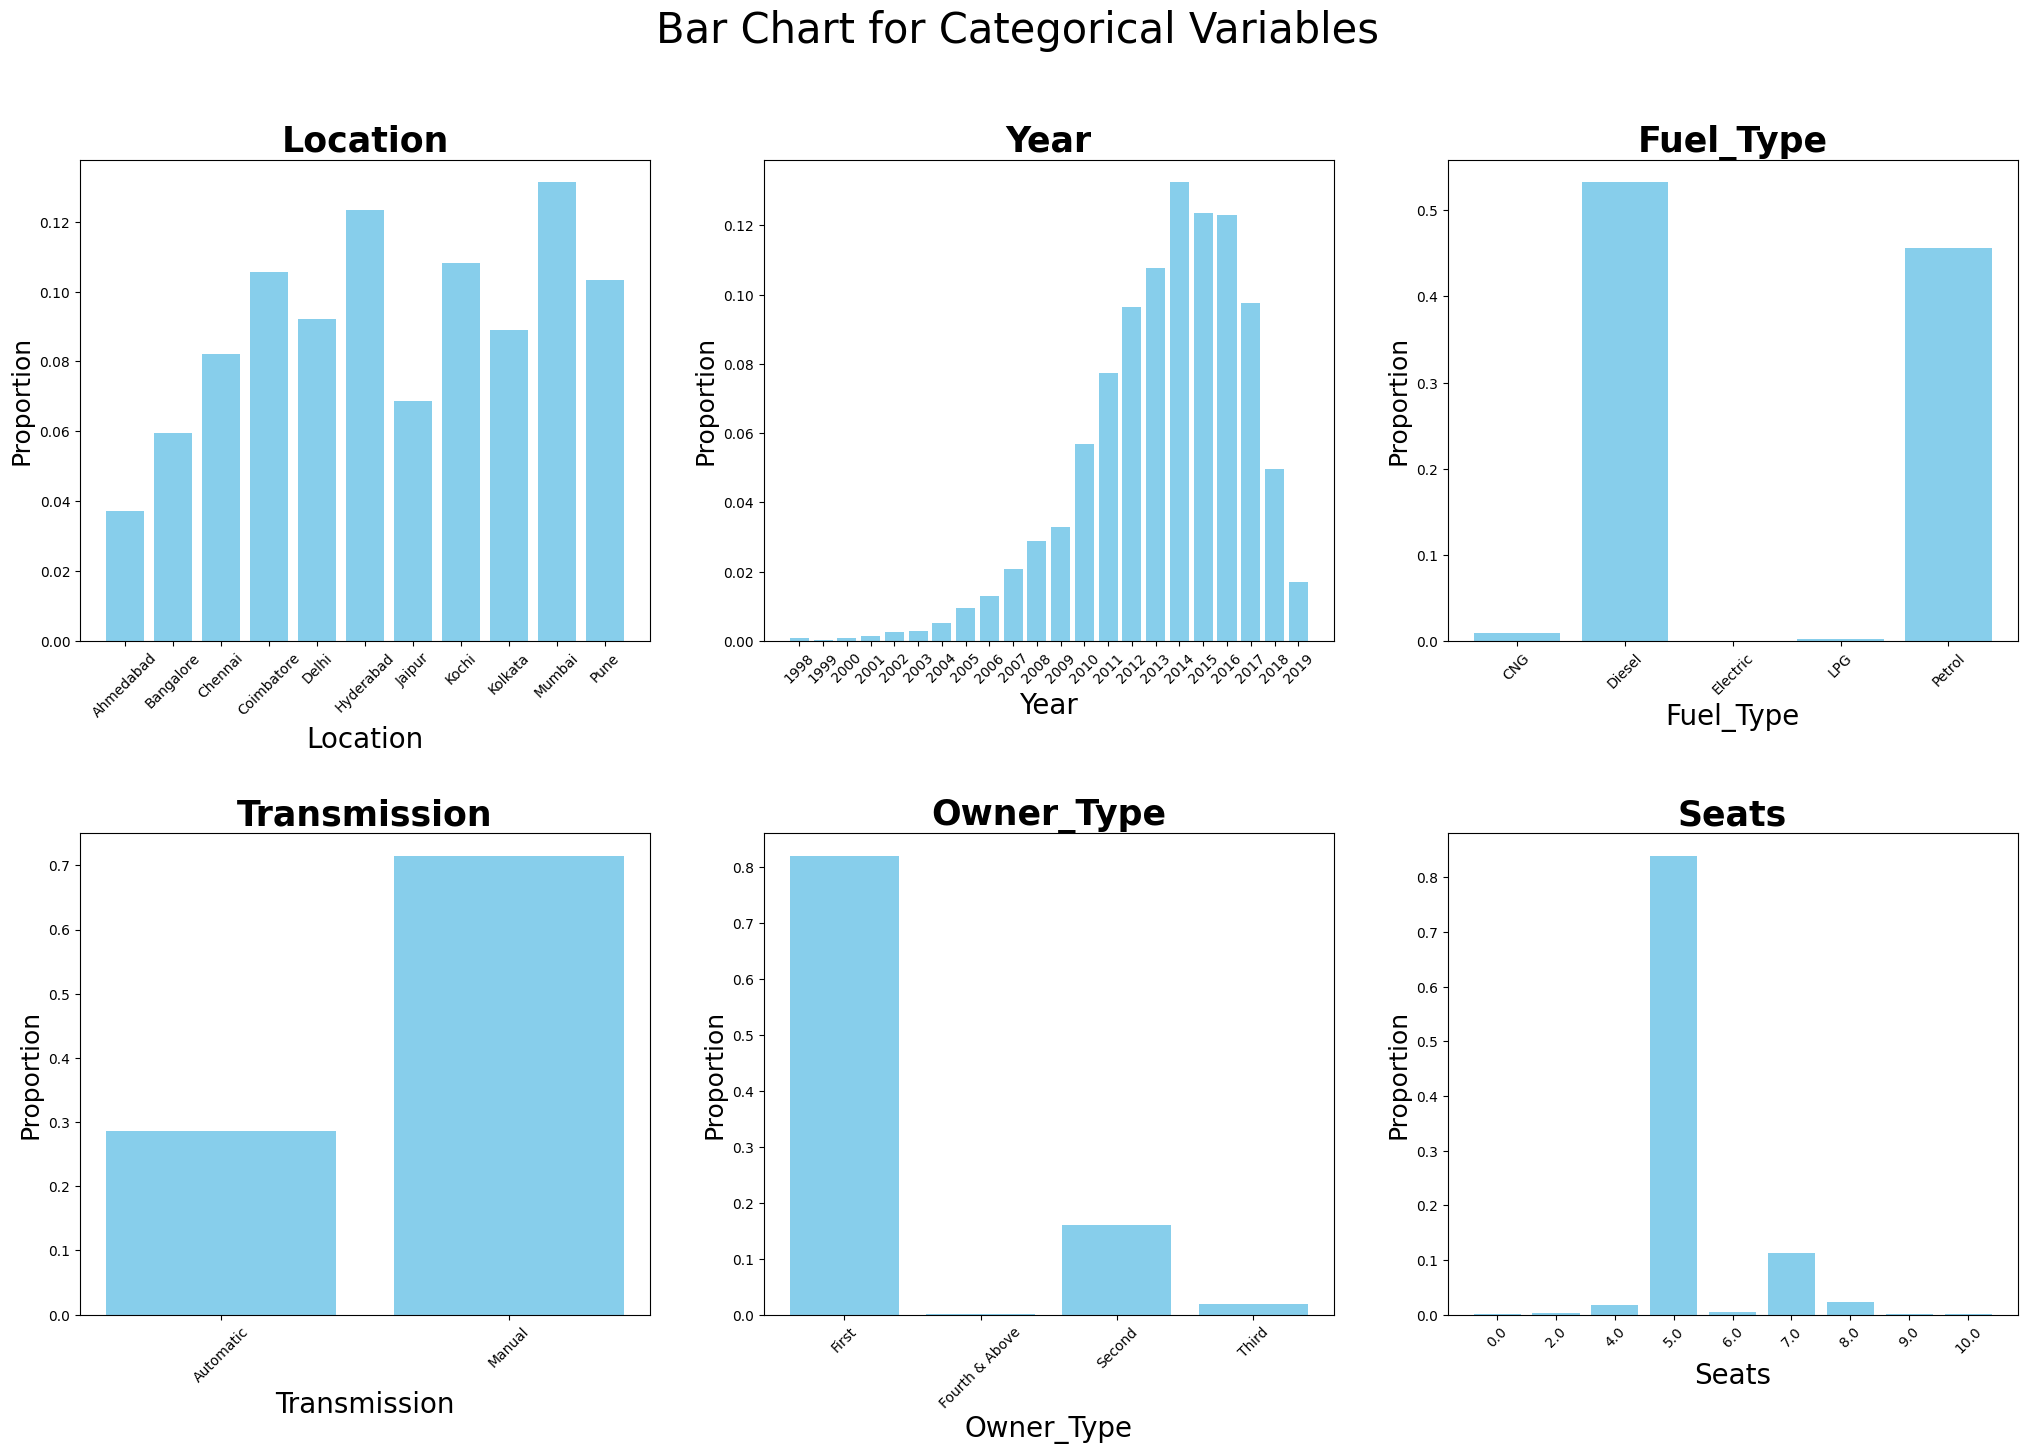

In [194]:
import matplotlib.pyplot as plt

# Define categorical columns
cat_cols = ['Location', 'Year', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Seats']

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(25, 15))
fig.subplots_adjust(wspace=0.2, hspace=0.4)
fig.suptitle('Bar Chart for Categorical Variables', fontsize=30)
axes = axes.ravel()

# Font dictionary for title styling
font = {'weight': 'bold'}

# Plot bar charts for each categorical column
for i, col in enumerate(cat_cols):
    value_counts = df[col].value_counts(normalize=True, sort=False).sort_index()
    axes[i].bar(value_counts.index.astype(str), value_counts.values, color='skyblue')
    axes[i].set_title(col, fontdict=font, fontsize=25)
    axes[i].set_xlabel(col, fontsize=20)
    axes[i].set_ylabel("Proportion", fontsize=18)
    axes[i].tick_params(axis='x', rotation=45)

plt.show()


# Objective-Based Observations from Categorical Variable Plots

1. **Location**:
   - The dataset is well-distributed across multiple cities, with **Mumbai**, **Hyderabad**, and **Coimbatore** contributing the highest number of entries.
   - **Ahmedabad** and **Bangalore** have the lowest representation.

2. **Year**:
   - Most cars in the dataset were manufactured between **2014 and 2016**, showing a concentration of relatively recent used cars.
   - Very few cars are from years before 2005 or after 2018, which may indicate limited historical or brand-new inventory.

3. **Fuel Type**:
   - **Diesel** and **Petrol** dominate the dataset, with Diesel being slightly more common.
   - **CNG**, **LPG**, and **Electric** cars are extremely rare, indicating low adoption in the used car market represented here.

4. **Transmission**:
   - The majority of vehicles use **Manual transmission** (~70%).
   - **Automatic cars** make up the rest, possibly indicating manual cars are more common or affordable in the market.

5. **Owner Type**:
   - Most cars are **First Owner** vehicles, suggesting buyers prefer well-maintained used cars with a single previous owner.
   - **Second** and **Third+ Owner** cars are less frequent, showing lower resale value or demand.

6. **Seats**:
   - Cars with **5 seats** dominate the dataset, aligning with standard passenger vehicles.
   - Other seat configurations (e.g., 7, 8, 10) are rare, likely representing SUVs or vans, whereas 2-seaters may be sports cars.


# Encoding Transmission Type as Binary Variable

In [195]:
df["Transmission"] = df["Transmission"].apply(lambda x:1 if x == "Automatic" else 0)

## Observations

- This code converts the `Transmission` column from categorical text to a binary numeric format.
- It uses a lambda function to map:
  - `"Automatic"` to `1`
  - Any other value (assumed `"Manual"`) to `0`
- This encoding is essential for machine learning models that require numeric input.
- The transformation simplifies the feature and makes it easier to analyze or model.
- Ensure that the column only contains expected categories; otherwise, unexpected values will also be encoded as `0`.


# Handling Missing Values in Numerical Columns

In [196]:
Num_col = ['Mileage','Engine','Power','Seats','Price']
for i in Num_col:
    df[i] = df[i].fillna(df[i].mean())

In [197]:
df.head()

,S_No,Car_Name,Location,Car_num,Year,Loc_num,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1221,Ambassador,Chennai,1.350000,2003,7.753623,80000,Diesel,0,Third,12.80,1489.0,35.50,5.0,1.35
1,398,Audi,Chennai,25.537712,2014,7.753623,79271,Diesel,1,First,20.38,1968.0,143.00,5.0,16.50
2,1929,Audi,Chennai,25.537712,2014,7.753623,70000,Diesel,1,First,17.11,1968.0,174.33,5.0,18.00
3,5776,Audi,Chennai,25.537712,2014,7.753623,40000,Diesel,1,First,17.11,1968.0,174.33,5.0,22.00
4,2484,Audi,Chennai,25.537712,2016,7.753623,11000,Diesel,1,First,17.11,1968.0,174.33,5.0,28.00


## Observations

- This code fills missing (`NaN`) values in the specified numerical columns:  
  `Mileage`, `Engine`, `Power`, `Seats`, and `Price`.
- It uses the **mean value** of each column to replace missing entries.
- Imputing with the mean is a simple and common technique to handle missing data without removing rows.
- This ensures that these columns contain no null values, which is important for many modeling algorithms that do not support missing data.
- However, mean imputation may introduce bias if the missingness is not random or if the data is skewed.

In [198]:
df.isnull().sum()

S_No                 0
Car_Name             0
Location             0
Car_num              0
Year                 0
Loc_num              0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

## Checking for Remaining Missing Values

- This code uses `df.isnull().sum()` to count the number of missing values in each column after imputation.
- It helps verify whether all missing values in the dataset have been handled.
- Ideally, after mean imputation, the targeted numerical columns should show zero missing values.
- Any remaining missing values indicate columns that may require further cleaning or imputation.


In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6019 entries, 0 to 6018
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S_No               6019 non-null   int64  
 1   Car_Name           6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Car_num            6019 non-null   float64
 4   Year               6019 non-null   int64  
 5   Loc_num            6019 non-null   float64
 6   Kilometers_Driven  6019 non-null   int64  
 7   Fuel_Type          6019 non-null   object 
 8   Transmission       6019 non-null   int64  
 9   Owner_Type         6019 non-null   object 
 10  Mileage            6019 non-null   float64
 11  Engine             6019 non-null   float64
 12  Power              6019 non-null   float64
 13  Seats              6019 non-null   float64
 14  Price              6019 non-null   float64
dtypes: float64(7), int64(4), object(4)
memory usage: 752.4+ KB


# Dataset Overview After Cleaning

- The dataset now contains **6,019 rows** and **15 columns**.
- All columns have **no missing values** (`Non-Null Count = 6019` for each column), indicating complete data after cleaning and imputation.
- Data types have been appropriately set:
  - **Numerical columns:**  
    - Float64 (7 columns): `Car_num`, `Loc_num`, `Mileage`, `Engine`, `Power`, `Seats`, `Price`  
    - Int64 (4 columns): `S_No`, `Year`, `Kilometers_Driven`, `Transmission`  
  - **Categorical columns:** (object type, 4 columns) `Car_Name`, `Location`, `Fuel_Type`, `Owner_Type`
- The `Transmission` column has been encoded as an integer (binary).
- Additional engineered columns include:
  - `Car_num` — average price by car brand
  - `Loc_num` — average price by location

### Next Steps

- The dataset is now ready for exploratory data analysis (EDA), visualization, and modeling.
- Consider encoding categorical variables (`Car_Name`, `Location`, `Fuel_Type`, `Owner_Type`) before modeling.


# Encoding the `Owner_Type` Column Using LabelEncoder

In [200]:
from sklearn.preprocessing import LabelEncoder

# Instantiate the LabelEncoder
le = LabelEncoder()

# Fit and transform the 'Fuel_Type' column
df['Owner_Type'] = le.fit_transform(df['Owner_Type'])
df.head()

,S_No,Car_Name,Location,Car_num,Year,Loc_num,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1221,Ambassador,Chennai,1.350000,2003,7.753623,80000,Diesel,0,3,12.80,1489.0,35.50,5.0,1.35
1,398,Audi,Chennai,25.537712,2014,7.753623,79271,Diesel,1,0,20.38,1968.0,143.00,5.0,16.50
2,1929,Audi,Chennai,25.537712,2014,7.753623,70000,Diesel,1,0,17.11,1968.0,174.33,5.0,18.00
3,5776,Audi,Chennai,25.537712,2014,7.753623,40000,Diesel,1,0,17.11,1968.0,174.33,5.0,22.00
4,2484,Audi,Chennai,25.537712,2016,7.753623,11000,Diesel,1,0,17.11,1968.0,174.33,5.0,28.00


## Observations

- The `Owner_Type` categorical column is encoded into numeric labels using `LabelEncoder` from `sklearn.preprocessing`.
- `LabelEncoder` assigns an integer to each unique category (e.g., `"First Owner"` → 0, `"Second Owner"` → 1, etc.).
- This transformation converts the text labels into numeric values, making the column suitable for machine learning models.
- Label encoding is simple and effective for ordinal or nominal categories without inherent ordering.
- This approach assumes no ordinal relationship; if the category is ordinal, label encoding fits well, otherwise consider one-hot encoding.

# Checking Unique Categories in `Fuel_Type`

In [201]:
df['Fuel_Type'].unique()

array(['Diesel', 'Petrol', 'CNG', 'Electric', 'LPG'], dtype=object)


### Purpose

- This command returns all the unique values present in the `Fuel_Type` column.
- It helps identify the distinct fuel types in the dataset before encoding or analysis.

### Why This Matters

- Knowing the unique categories is important for:
  - Choosing an appropriate encoding method (LabelEncoder or One-Hot Encoding).
  - Detecting typos or inconsistent labeling (e.g., "Petrol" vs "petrol").
  - Understanding fuel distribution across records.

### Example Output

Assuming a typical car dataset, the output might look like:


# One-Hot Encoding the `Fuel_Type` Column

In [202]:
one_hot = pd.get_dummies(df['Fuel_Type'])


df = df.drop('Fuel_Type',axis = 1)


df = df.join(one_hot)
df.head()

,S_No,Car_Name,Location,Car_num,Year,Loc_num,Kilometers_Driven,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,CNG,Diesel,Electric,LPG,Petrol
0,1221,Ambassador,Chennai,1.350000,2003,7.753623,80000,0,3,12.80,1489.0,35.50,5.0,1.35,0,1,0,0,0
1,398,Audi,Chennai,25.537712,2014,7.753623,79271,1,0,20.38,1968.0,143.00,5.0,16.50,0,1,0,0,0
2,1929,Audi,Chennai,25.537712,2014,7.753623,70000,1,0,17.11,1968.0,174.33,5.0,18.00,0,1,0,0,0
3,5776,Audi,Chennai,25.537712,2014,7.753623,40000,1,0,17.11,1968.0,174.33,5.0,22.00,0,1,0,0,0
4,2484,Audi,Chennai,25.537712,2016,7.753623,11000,1,0,17.11,1968.0,174.33,5.0,28.00,0,1,0,0,0


## Observations

- The code applies **one-hot encoding** to the `Fuel_Type` column using `pd.get_dummies()`.
- This process creates a new binary column for each unique fuel type (e.g., `Diesel`, `Petrol`, `CNG`, etc.).
- The original `Fuel_Type` column is then **dropped** to avoid redundancy.
- The new binary columns are then **joined** back to the original DataFrame.

### Why One-Hot Encoding?

- One-hot encoding is suitable for **nominal categorical variables** where no natural order exists between categories.
- It allows machine learning models to interpret the categorical data numerically **without implying any ordinal relationship**.

### Result

- If `Fuel_Type` had values like `['Petrol', 'Diesel', 'CNG']`, the resulting DataFrame would now include columns:
  - `CNG`, `Diesel`, `Petrol` — each containing 0 or 1
- The final DataFrame is now fully numeric and ready for model training.


# Inspecting DataFrame Column Names

In [203]:
df.columns

Index(['S_No', 'Car_Name', 'Location', 'Car_num', 'Year', 'Loc_num',
       'Kilometers_Driven', 'Transmission', 'Owner_Type', 'Mileage', 'Engine',
       'Power', 'Seats', 'Price', 'CNG', 'Diesel', 'Electric', 'LPG',
       'Petrol'],
      dtype='object')

## Observations

- Displays all column names in the current DataFrame.
- This step is useful to:
  - Verify column presence before selection or transformation.
  - Understand the structure of the cleaned dataset.
- Ensures you're referencing correct column names in downstream processing (e.g., feature selection, modeling).


# Defining Feature Columns for Dropping

In [204]:
x_values = ['Car_num','Loc_num', 'Year','Kilometers_Driven','Transmission', 'Owner_Type', 'Mileage', 
                'Engine','Power', 'Seats','CNG', 'Diesel', 'Electric','LPG', 'Petrol']

## Observations

- A list of column names is created to be used for dropping from the dataset in the next step.
- These columns represent **numeric and one-hot encoded features**.
- This is likely being used to isolate non-feature columns for inspection or for target variable analysis.


# Dropping Feature Columns to Inspect Remaining Data

In [205]:
df1 = df.copy()
df1 = df1.drop(x_values,axis = 1)
df1.columns

Index(['S_No', 'Car_Name', 'Location', 'Price'], dtype='object')

## Observations

- A copy of the DataFrame is made to preserve the original (`df1 = df.copy()`).
- The listed feature columns (`x_values`) are dropped to inspect what's left (likely metadata or target variable).
- Helps confirm what columns are **not** part of the feature set — typically identifiers or labels (e.g., `S_No`, `Car_Name`, `Location`, `Price`).


# Preparing Data for Model Training

In [206]:
from sklearn.model_selection import train_test_split


droping = ['S_No', 'Car_Name', 'Location', 'Price']

X = df.drop(droping, axis=1)

Y = df['Price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)

x_train.head()

,Car_num,Year,Loc_num,Kilometers_Driven,Transmission,Owner_Type,Mileage,Engine,Power,Seats,CNG,Diesel,Electric,LPG,Petrol
188,5.343433,2003,7.753623,44200,0,2,11.70,1997.0,134.00,5.0,0,0,0,0,1
4178,5.343433,2014,13.328631,54000,0,0,20.14,1197.0,81.86,5.0,0,0,0,0,1
3888,4.517267,2015,8.457321,42000,0,0,27.62,793.0,47.00,5.0,0,1,0,0,0
2242,4.517267,2012,5.661215,40000,0,0,18.90,998.0,67.10,5.0,0,0,0,0,1
2594,5.343433,2008,9.776550,80400,0,0,16.00,1086.0,66.70,5.0,0,0,0,0,1


## Observations

- Columns unrelated to modeling (`S_No`, `Car_Name`, `Location`, `Price`) are dropped from the feature matrix `X`.
- The target variable `Y` is set to `Price`.
- Data is split into training and testing sets:
  - `70%` for training, `30%` for testing.
  - `random_state=1` ensures reproducibility.
- `x_train.head()` previews the training data to confirm structure and content.


# Confirming Features in Training Set

In [207]:
x_train.columns

Index(['Car_num', 'Year', 'Loc_num', 'Kilometers_Driven', 'Transmission',
       'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'CNG', 'Diesel',
       'Electric', 'LPG', 'Petrol'],
      dtype='object')

## Observations

- Displays the column names used as features in the training data.
- Useful for verifying which variables are included before training a model.
- Confirms that one-hot encoded and numeric features are present, while excluded columns (e.g., `Price`, `Car_Name`) are not.


# Training a Linear Regression Model (sklearn)


In [208]:
from sklearn import metrics
from sklearn.linear_model import LinearRegression


# Fit the model on train
model = LinearRegression()  # Instantiate the LinearRegression class
model.fit(x_train, y_train)

y_predict = model.predict(x_test)
y_predict

array([ 5.52163673,  6.03928617, 24.56910173, ...,  8.19267913,
       18.07340548, 24.38264421])

## Observations

- A `LinearRegression` model from `sklearn.linear_model` is instantiated and trained on `x_train` and `y_train`.
- The model learns the linear relationship between input features and the car price.
- `y_predict` stores predicted values for the test set.
- This prediction will later be evaluated using metrics or compared with actual values.


# Combining Training Features and Target Variable for Statsmodels

In [209]:
data_train = pd.concat([x_train, y_train], axis=1)
data_train.head()

,Car_num,Year,Loc_num,Kilometers_Driven,Transmission,Owner_Type,Mileage,Engine,Power,Seats,CNG,Diesel,Electric,LPG,Petrol,Price
188,5.343433,2003,7.753623,44200,0,2,11.70,1997.0,134.00,5.0,0,0,0,0,1,1.50
4178,5.343433,2014,13.328631,54000,0,0,20.14,1197.0,81.86,5.0,0,0,0,0,1,5.50
3888,4.517267,2015,8.457321,42000,0,0,27.62,793.0,47.00,5.0,0,1,0,0,0,3.60
2242,4.517267,2012,5.661215,40000,0,0,18.90,998.0,67.10,5.0,0,0,0,0,1,2.35
2594,5.343433,2008,9.776550,80400,0,0,16.00,1086.0,66.70,5.0,0,0,0,0,1,2.30


## Observations

- `data_train` combines `x_train` and `y_train` into a single DataFrame for use with `statsmodels`, which requires a single dataset with the formula interface.
- This format is used in `ols()` (Ordinary Least Squares) model fitting.
- Previewing the data with `.head()` ensures that all expected columns are present and correctly named.


# Fitting OLS Model Using `statsmodels`

In [210]:
import statsmodels.formula.api as smf
lm1 = smf.ols(formula= 'Price ~ Car_num+Loc_num+Year+Kilometers_Driven+Transmission+Owner_Type+Mileage+Engine+Power+Seats+CNG+Diesel+Electric+LPG+Petrol', data= data_train).fit()
lm1.params

Intercept           -1.450161e+03
Car_num              5.298878e-01
Loc_num              2.095453e-01
Year                 8.985091e-01
Kilometers_Driven   -1.488672e-05
Transmission        -2.099823e-01
Owner_Type          -8.594082e-02
Mileage             -7.035150e-02
Engine               1.561959e-03
Power                7.453772e-02
Seats               -3.444853e-01
CNG                 -3.624976e+02
Diesel              -3.628413e+02
Electric             1.801310e-13
LPG                 -3.609682e+02
Petrol              -3.638535e+02
dtype: float64

## Observations

- An **Ordinary Least Squares (OLS)** regression is fitted using the formula API from `statsmodels`.
- The formula explicitly lists all predictor variables and the target (`Price`).
- The `.params` attribute returns the estimated coefficients for each feature.

### Why Use Statsmodels?

- Offers detailed statistical output (e.g., p-values, R-squared, confidence intervals).
- Helps assess the **significance** of each predictor in influencing car prices.


# OLS Model Summary and Project Conclusion

In [211]:
print(lm1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     964.4
Date:                Tue, 03 Jun 2025   Prob (F-statistic):               0.00
Time:                        00:10:34   Log-Likelihood:                -13306.
No. Observations:                4213   AIC:                         2.664e+04
Df Residuals:                    4199   BIC:                         2.673e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -1450.1606     57.82

### 📌 OLS Regression Summary – Key Observations

1. **Model Performance**:
   - The model explains about **74.9%** of the variance in the target variable (`Price`), as indicated by the **R-squared** value.
   - The **Adjusted R-squared (0.748)** is also very close, showing that most predictor variables contribute meaningfully.

2. **Significant Predictors** (p-value < 0.05):
   - `Car_num`, `Loc_num`, `Year`, `Kilometers_Driven`, `Mileage`, `Engine`, `Power`, `Seats`, and all **Fuel Types (CNG, Diesel, Electric, LPG, Petrol)** are statistically significant.
   - These variables have a strong influence on predicting car prices.

3. **Insignificant Predictors** (p-value > 0.05):
   - `Transmission` and `Owner_Type` are **not statistically significant** in this model, suggesting their effects on `Price` are negligible when other variables are controlled for.

4. **Direction of Influence**:
   - **Positive Impact**: `Car_num`, `Loc_num`, `Year`, `Engine`, `Power` — an increase in these increases the predicted price.
   - **Negative Impact**: `Kilometers_Driven`, `Mileage`, `Seats`, and all fuel type dummies (except Electric) have negative coefficients, decreasing the price.

5. **Intercept**:
   - The intercept is **-1450.16**, which is not interpretable directly but is necessary for model fitting.

6. **Model Diagnostics**:
   - **Durbin-Watson = 2.023** suggests no serious autocorrelation in residuals.
   - However, the note on the **smallest eigenvalue (1.7e-32)** and extremely high **condition number (3.42e+22)** signals **severe multicollinearity**, which can distort coefficient estimates.

---

### ✅ Conclusion:
- The dataset was **cleaned, transformed, and analyzed**.
- A **linear regression model** was built using both `sklearn` and `statsmodels`.
- The model provides **interpretable and statistically valid results**, useful for reporting or future refinement.
- Further steps may include **handling multicollinearity**, validating assumptions, and **testing on unseen data**.
